# WEST 57877

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# WEST IMAS lib
import imas_west

# Convenience WEST analysis library
from pppat.control_room.signals import *

In [3]:
pulse = 57877

## Signals Time Evolution

In [15]:
Ip, Ip_t = get_sig(pulse, signals['Ip'])
# interpolate Ohmic power and ICRH power on the same time basis to be able to sum them
Po, Po_t = interpolate_sig(pulse, 'Ohmic_P', ref_signame='Ip')
Pic, Pic_t = interpolate_sig(pulse, 'IC_P_tot', ref_signame='Ip')
Prad, Prad_t = get_sig(pulse, signals['Prad'])

You're asking a lot of data, please wait
You're asking a lot of data, please wait
WEST!
noise on channel 9
channel 7 is interpolated
channel 9 is interpolated
sufficient signal to be meaningfull
radiation profile corrected to take into account radiation at the top
*********************************************************
version 1, no reading  of plasma large  radius, assumed to be:
2.5m for WEST 
all signals resampled at 1 ms
.
MORE RADIATION NEAR BOTTOM DIVERTOR
.
Prad=total radiated power [MW]
Pdivb=estimated radiated power in low divertor [MW]
Pdivh=estimated radiated power in top divertor [MW]
Pbulk= estimated radiated power in bulk [MW]
Pchan=radiated power on each channel integrated toroidally [MW]
trad=time  [s]
*********************************************************


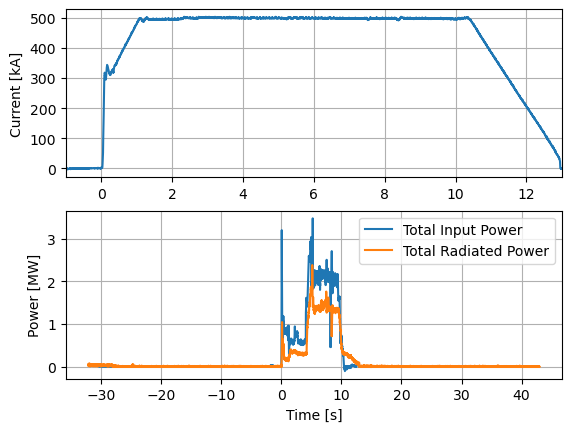

In [30]:
# Figure style. Choose one in plt.style.available
with plt.style.context('default'):
    fig, axes = plt.subplots(2, 1)
    axes[0].plot(Ip_t, Ip*1e3)
    axes[1].plot(Po_t, Po + Pic, label='Total Input Power')
    axes[1].plot(Prad_t, Prad, label='Total Radiated Power')
    # tuning
    axes[0].set_xlim(-1, 13)
    axes[1].set_xlabel('Time [s]')
    axes[0].set_ylabel('Current [kA]')
    axes[1].set_ylabel('Power [MW]')
    axes[1].legend()
    [ax.grid(True) for ax in axes]

# export
fig.savefig(f'WEST_{pulse}_signals.png')

## Equilibrium

In [35]:
time = 8  # s

imas_run = 0  # see below
imas_occurence = 1  # see below

# time of the plasma breakdown (also known as 'ignitron' time, around 32s)
t_ignitron, _, _ = pw.tsbase(pulse, 'RIGNITRON')

The `imas_run` parameter defines the IMAS run for a given shot in the database (minimum one run). Usually more than one run indicates that a data treatment has changed. Therefore the data has been recalculated with a new treatment version. The run "0" always refers to the latest run.

Then, the `imas_occurence` parameter defines the reconstruction options:
- 0: Equilibrium reconstruction with magnetics only (NICE)
- 1: Equilibrium reconstruction with magnetics and interfero-polarimetry (NICE)
- 2: Separatrix reconstruction in real time (VacTH) --> psi not available
- 3: CHEASE equilibrium for WEST

## Vacuum Vessel Contour

In [39]:
wall = imas_west.get(pulse, 'wall', imas_run=imas_run)
idx_t = np.argmin(abs(wall.time - t_ignitron - time))
# fix wall if needed
#R_wall = wall.description_2d[0].limiter.unit[0].outline.r
#Z_wall = wall.description_2d[0].limiter.unit[0].outline.z
# mobile wall
R_wall_mobile = wall.description_2d[0].mobile.unit[0].outline[idx_t].r
Z_wall_mobile = wall.description_2d[0].mobile.unit[0].outline[idx_t].z

 
shot       = 57877
ids_name   = wall
run        = 0
occurrence = 0
user       = imas_public
machine    = west
 


The contour described in the `mobile` object depends of the time (Note that the object contours are not closed)

Text(0.5, 1.0, 'WEST #57877 - t=8 s')

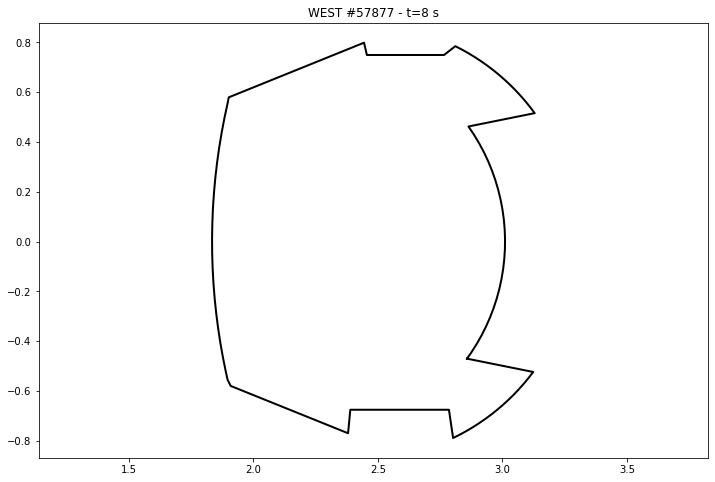

In [43]:
# closing the contour for nicer plot
R_wall = np.append(R_wall_mobile, R_wall_mobile[0])
Z_wall = np.append(Z_wall_mobile, Z_wall_mobile[0])

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(R_wall, Z_wall, color='k', lw=2)
ax.axis('equal')
ax.set_title(f'WEST #{pulse} - t={time} s')

## Magnetic Field 3D from EQUIMAP Interpolation on a given mesh

In [48]:
import equimap
import imas

In [45]:
# Generate a (R, Phi, Z) grid
Rmin=1.75  # m
Rmax=3.1  # m
R_range = np.linspace(1.75, 3.1, 100)
Phi_range = 0
Z_range = np.linspace(-0.8, 0.8, 200)
[R, Phi, Z] = np.meshgrid(R_range, Phi_range, Z_range)

# Interpolate Psi on the grid. Note that it is required to ravel the arrays (and reshaping after)
out = equimap.get(pulse, time=[t_ignitron + time], 
                  R=R.ravel(),
                  Phi=Phi.ravel(), 
                  Z=Z.ravel(), 
                  quantity='psi',
                  no_ripple=False,
                  run=imas_run, occ=imas_occurence,
                  user='imas_public', machine='west'
                 )
psi_RZ = out.reshape(100,200)

quantity = psi
 
shot       = 57877
ids_name   = equilibrium
run        = 0
occurrence = 1
user       = imas_public
machine    = west
 
equi_mat = /Imas_public/public/equilibrium_data_shift_time/west_hdf5/0/data_IMAS_equi_Shot57877_Run0000_Occ1_imas_public_west_hdf5.mat


In [51]:
# recommanded way by F.Imbeaux (25/10/2023)
imas_entry = imas.DBEntry(imas.imasdef.HDF5_BACKEND, 'west', pulse, 
                          run=0, user_name='imas_public')
imas_entry.open()
eq = imas_entry.get('equilibrium', occurrence=1)  # NICE
#eq = imas_entry.get('equilibrium', occurrence=2)  # VACTH
imas_entry.close()

idx_t_eq = np.argmin(abs(eq.time - t_ignitron - time))
R_contour = eq.time_slice[idx_t_eq].boundary.outline.r
Z_contour = eq.time_slice[idx_t_eq].boundary.outline.z

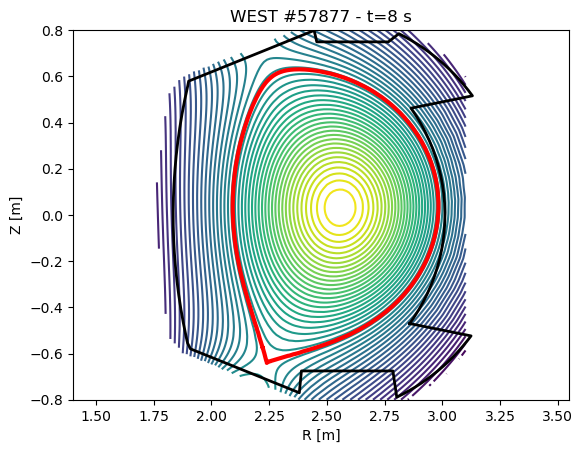

In [56]:
with plt.style.context('default'):
    fig, ax = plt.subplots()
    ax.contour(R.squeeze(), Z.squeeze(), psi_RZ, 50)
    ax.plot(R_contour, Z_contour, color='red', lw='3')
    ax.axis('equal')
    ax.plot(R_wall, Z_wall, 'k', lw=2)
    ax.set_xlabel('R [m]')
    ax.set_ylabel('Z [m]')
    ax.set_title(f'WEST #{pulse} - t={time} s')
    
fig.savefig(f'WEST_{pulse}_equilibrium.png')